# Knight's Walk

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Part 1 - Initialize the board


https://www.youtube.com/watch?v=RGQe8waGJ4w (runtime: 6:12)

We will store the chess board in a 2d- numpy array of integers. The size of the board is $(2n+1)$-by-$(2n+1)$, for a given integer $n$. This means the board extends from the center square by $n$ steps in all directions.

The first step is to initialize the board by filling it with the integers described in the video. Finish the implementation of the function definition in the cell below such that it returns this "spiral pattern" for any given input parameter $n$.

An example is given below: for the following input
```python
board = initialize_board(3)
```
the correct output is
```julia
7×7 Array{Int64,2}:
 37  36  35  34  33  32  31
 38  17  16  15  14  13  30
 39  18   5   4   3  12  29
 40  19   6   1   2  11  28
 41  20   7   8   9  10  27
 42  21  22  23  24  25  26
 43  44  45  46  47  48  49
```

Test your function for various values of $n$ to make sure it is correct before you continue.

*Hints*:
- Note that since Python uses 0-based indexing, the center square of the array `board` is given by element `board[n,n]`.
- After the center $1$ has been placed, there are exactly $n$ "circles" of numbers of increasing radius. This is naturally implemented using a for-loop.
- In each "circle", there are 4 segments going up, left, down, and right. These are also naturally implemented using a sequence of 4 for-loops.

In [3]:
def initialize_board(n):
    dim_board = 2*n + 1
    board = np.zeros((dim_board, dim_board), dtype=int)

    # Set the center of the board as the starting position
    center = n
    board[center, center] = 1

    # Set the rest of the board in increasing order from the center
    value = 2
    for circle in range(1, n+1):
        for up in range(n+circle,n-circle,-1): #right segment
            board[up-1, n+circle] = value
            value+=1

        for left in range(n+circle,n-circle,-1): #top segment
            board[n-circle, left-1] = value
            value+=1

        for down in range(n-circle,n+circle): #left segment
            board[down+1, n-circle] = value
            value+=1

        for right in range(n-circle,n+circle): #bottom segment
            board[n+circle,right+1] = value
            value+=1

    return board

In [4]:
# Use the initialize_board function to create a board
initialize_board(2)

array([[17, 16, 15, 14, 13],
       [18,  5,  4,  3, 12],
       [19,  6,  1,  2, 11],
       [20,  7,  8,  9, 10],
       [21, 22, 23, 24, 25]])

In [5]:
def initialize_board_alt(n):
    dim_board = 2*n + 1
    board = np.zeros((dim_board, dim_board), dtype=int)

    # Set the center of the board as the starting position
    x, y = n, n
    board[x, y] = 1

    value = 2

    for circle in range(n):
        x+=1
        y+=1
        steps = 2*(circle+1)
        for _ in range(steps):
            x -= 1
            board[x, y] = value
            value += 1

        for _ in range(steps):
            y -= 1
            board[x, y] = value
            value += 1

        for _ in range(steps):
            x += 1
            board[x, y] = value
            value += 1

        for _ in range(steps):
            y += 1
            board[x, y] = value
            value += 1

    return board

In [6]:
initialize_board_alt(2)

array([[17, 16, 15, 14, 13],
       [18,  5,  4,  3, 12],
       [19,  6,  1,  2, 11],
       [20,  7,  8,  9, 10],
       [21, 22, 23, 24, 25]])

In [7]:
board = initialize_board(2)
board[3,2]

np.int64(8)

### Part 2 - Simulate the walk


Next we will write the function to simulate the walk and produce the sequence. This function will take an initialized board as input, and produce a list of numbers as well as the corresponding x- and y-coordinates.

For example, the following input:
```julia
board = initialize_board(2)
display(board)
seq, xs, ys = simulate_walk(board);
print("Sequence = ", seq)
print("x-coordinates = ", xs)
print("y-coordinates = ", ys)
```
should produce the following correct output:
```julia
5×5 Array{Int64,2}:
 17  16  15  14  13
 18   5   4   3  12
 19   6   1   2  11
 20   7   8   9  10
 21  22  23  24  25
Sequence = [1, 10, 3, 6, 9, 4, 7, 2, 5, 8, 11, 14]
x-coordinates = [0, 2, 1, -1, 1, 0, -1, 1, -1, 0, 2, 1]
y-coordinates = [0, 1, -1, 0, 1, -1, 1, 0, -1, 1, 0, -2]
```

Again test your code, first using small values of $n$ as shown above, which makes it easier to look at the results and find errors.

*Hints*:
- It is convenient to create another 2d-array of booleans, indicating if a square has been visited or not.
- Make sure you never allow the knight to jump outside the board. That is, the only valid positions are $n$ steps from the center square in either direction

In [15]:
def simulate_walk(board):
    sequence = []; x_coordinates = []; y_coordinates = []
    visited = np.zeros(board.shape, dtype=bool)
    start_pos = np.argwhere(board == 1)[0]
    y, x = int(start_pos[0]), int(start_pos[1])
    
    def add_values(y_new, x_new):
        visited[y_new, x_new] = True
        sequence.append(int(board[y_new, x_new]))
        x_coordinates.append(x_new - start_pos[1])
        y_coordinates.append(y_new - start_pos[0])

    add_values(y, x)

    # Define possible knight moves
    knight_moves = [
        (-2, -1), (-1, -2), (1, -2), (2, -1),
        (2, 1), (1, 2), (-1, 2), (-2, 1)
    ]

    while True:
        possible_moves = []
        for dy, dx in knight_moves:
            new_y, new_x = y + dy, x + dx
            if 0 <= new_y < board.shape[0] and 0 <= new_x < board.shape[1] and not visited[new_y, new_x]:
                possible_moves.append((new_y, new_x))

        if not possible_moves:
            break

        values = [board[new_y, new_x] for new_y, new_x in possible_moves]
        min_value = min(values)

        new_y, new_x = possible_moves[values.index(min_value)]
        add_values(new_y, new_x)
        y, x = new_y, new_x

    return(sequence, x_coordinates, y_coordinates)

In [9]:
board = initialize_board(2)
display(board)
sequence,x_coordinates,y_coordinates = simulate_walk(board)
print("Sequence = ", sequence)
print("x-coordinates = ", x_coordinates)
print("y-coordinates = ", y_coordinates)

array([[17, 16, 15, 14, 13],
       [18,  5,  4,  3, 12],
       [19,  6,  1,  2, 11],
       [20,  7,  8,  9, 10],
       [21, 22, 23, 24, 25]])

Sequence =  [1, 10, 3, 6, 9, 4, 7, 2, 5, 8, 11, 14]
x-coordinates =  [2, 4, 3, 1, 3, 2, 1, 3, 1, 2, 4, 3]
y-coordinates =  [2, 3, 1, 2, 3, 1, 3, 2, 1, 3, 2, 0]


last element =  2084
with coordinates (110,77)


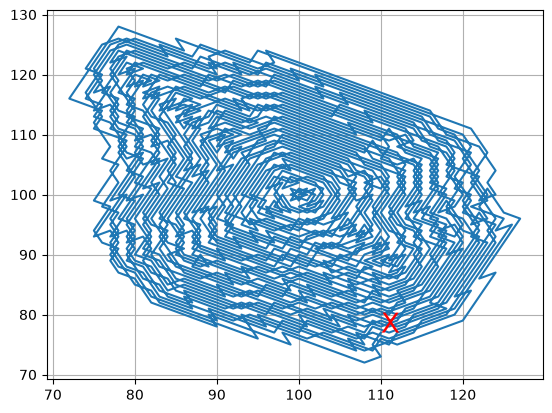

In [10]:
n = 100
board = initialize_board(n)
sequence,x_coordinates,y_coordinates = simulate_walk(board)

print("last element = ", int(sequence[-1]))
print(f"with coordinates ({x_coordinates[-1]},{y_coordinates[-1]})")

plt.plot(x_coordinates, y_coordinates)
plt.annotate('X',xy=(x_coordinates[-1],y_coordinates[-1]), color='red', size=20)
plt.grid()

n=28
last_element=2084
last_coordinate=(np.int64(10), np.int64(-23))


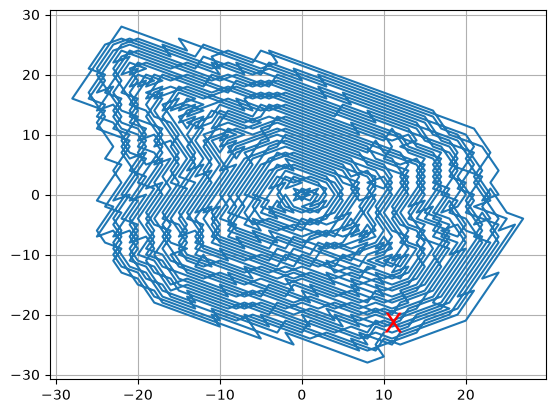

In [23]:
last_n = None
last_element = None
last_coordinate = None

for n in range(1, 200):
    board_t = initialize_board(n)
    sequence,x_coordinates,y_coordinates = simulate_walk(board_t)
    if last_element is not None and int(sequence[-1]) == last_element:
        n-=1 # repeated value from previous iteration
        print(f"{n=}")
        break
    board = board_t
    last_element = int(sequence[-1])
    last_coordinate = (x_coordinates[-1], y_coordinates[-1])


print(f"{last_element=}")
print(f"{last_coordinate=}")

# y_coordinates = np.negative(y_coordinates)
plt.plot(x_coordinates, y_coordinates)
plt.annotate('X',xy=(x_coordinates[-1],y_coordinates[-1]), color='red', size=20)
plt.grid()

In [24]:
b: np.ndarray = board
tuple(s//2 for s in b.shape) #explicit tuple otherwise only a generator would be created
max_y, max_x = (s//2 for s in b.shape)
max_y, max_x

(28, 28)

In [16]:
def simulate_walk_alt(board):
    sequence = []; x_coordinates = []; y_coordinates = []

    def add_values(y_new, x_new):
        visited[y_new, x_new] = True
        sequence.append(int(board[y_new, x_new]))
        x_coordinates.append(x_new - max_pos)
        y_coordinates.append(y_new - max_pos)

    
    x = 0; y = 0
    visited = np.zeros(board.shape, dtype=bool)
    board_size = np.size(board,0)
    max_pos = board_size//2

    # first position
    add_values(y+max_pos, x+max_pos)

    # move
    dead = False
    while not dead:
        board_min = pow(board_size,2)
        dead = True
        positions = ((x+2,y+1),(x+2,y-1),(x-2,y+1),(x-2,y-1),(x+1,y+2),(x+1,y-2),(x-1,y+2),(x-1,y-2))

        for test_x, test_y in positions:
            if abs(test_x) <= max_pos and abs(test_y) <= max_pos and not visited[test_y+max_pos, test_x+max_pos]:
                board_test = board[test_y+max_pos, test_x+max_pos]
                if board_test < board_min:
                    dead = False
                    board_min = board_test; x = test_x; y = test_y

        if not dead:
            add_values(y+max_pos, x+max_pos)
    
    return(sequence,x_coordinates,y_coordinates)


sequence,x_coordinates,y_coordinates = simulate_walk_alt(board)
print("Sequence = ", sequence)
print("x-coordinates = ", x_coordinates)
print("y-coordinates = ", y_coordinates)

Sequence =  [1, 10, 3, 6, 9, 4, 7, 2, 5, 8, 11, 14, 29, 32, 15, 12, 27, 24, 45, 20, 23, 44, 41, 18, 35, 38, 19, 16, 33, 30, 53, 26, 47, 22, 43, 70, 21, 40, 17, 34, 13, 28, 25, 46, 75, 42, 69, 104, 37, 62, 95, 58, 55, 86, 51, 48, 77, 114, 73, 108, 151, 68, 103, 64, 67, 36, 39, 66, 63, 96, 59, 56, 87, 52, 49, 78, 115, 74, 71, 106, 149, 102, 99, 140, 61, 94, 31, 54, 85, 50, 79, 116, 161, 76, 113, 72, 107, 150, 201, 146, 65, 98, 139, 60, 93, 90, 129, 176, 125, 82, 119, 164, 217, 160, 111, 154, 205, 264, 331, 200, 101, 142, 97, 138, 187, 92, 89, 128, 175, 84, 81, 118, 163, 216, 159, 110, 153, 204, 105, 148, 199, 144, 147, 100, 141, 190, 137, 186, 91, 130, 57, 88, 127, 174, 83, 80, 117, 162, 215, 112, 109, 152, 203, 262, 329, 198, 195, 252, 143, 192, 249, 188, 135, 132, 179, 234, 297, 230, 123, 120, 165, 218, 279, 214, 157, 208, 267, 334, 263, 330, 259, 196, 253, 318, 191, 248, 313, 244, 133, 180, 235, 298, 177, 126, 173, 122, 167, 220, 281, 350, 277, 158, 155, 206, 265, 202, 261, 328, 197, 

In [14]:
n = 100
def run1():
    Board = initialize_board(n)
    sequence,x_coordinates,y_coordinates = simulate_walk(Board)
    
def run2():
    Board = initialize_board(n)
    sequence,x_coordinates,y_coordinates = simulate_walk_alt(Board)
    
def run3():
    Board = initialize_board_alt(n)
    sequence,x_coordinates,y_coordinates = simulate_walk(Board)
    
def run4():
    Board = initialize_board_alt(n)
    sequence,x_coordinates,y_coordinates = simulate_walk_alt(Board)
    
%timeit run1()
%timeit run2()
%timeit run3()
%timeit run4()

14.4 ms ± 2.99 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
11.1 ms ± 1.61 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
10.9 ms ± 614 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
9.71 ms ± 1.97 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
